# 01 — Data Overview
**Phase 1 · Multi-fault Diagnosis of Rotating Machinery**

Goals:
- Inspect the MaFaulDa dataset folder structure and file count per class
- Preview raw signals from each fault condition
- Check class balance and sampling consistency

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
DATA_ROOT = Path("/kaggle/input/datasets/vuxuancu/mafaulda-full/mafaulda")
SAMPLING_RATE = 50_000  # Hz

CHANNEL_NAMES = [
    "tachometer",
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
    "microphone",
]

In [12]:
records = []

for csv_path in sorted(DATA_ROOT.rglob("*.csv")):
    parts = csv_path.relative_to(DATA_ROOT).parts
    # parts looks like one of these:
    #   ('normal', '12.288.csv')
    #   ('imbalance', '6g', '12.288.csv')
    #   ('horizontal-misalignment', '1.0mm', '12.288.csv')
    #   ('underhang', 'ball_fault', '20g', '12.288.csv')
    #   ('overhang', 'outer_race', '35g', '12.288.csv')

    fault_category = parts[0]
    filename = parts[-1]
    rotation_hz = float(filename.replace(".csv", ""))
    rotation_rpm = rotation_hz * 60
    frequency_hz = round(rotation_hz)

    # Defaults — will be overridden per category below.
    sub_type = None
    bearing_position = None
    severity = None
    severity_value = None
    severity_unit = None

    if fault_category == "normal":
        pass  # all defaults are fine

    elif fault_category == "imbalance":
        severity = parts[1]                          # e.g., '6g'
        severity_value = float(severity.replace("g", ""))
        severity_unit = "g"

    elif fault_category in ("horizontal-misalignment", "vertical-misalignment"):
        severity = parts[1]                          # e.g., '1.0mm'
        severity_value = float(severity.replace("mm", ""))
        severity_unit = "mm"

    elif fault_category in ("underhang", "overhang"):
        bearing_position = fault_category
        sub_type = parts[1]                          # 'ball_fault', 'cage_fault', 'outer_race'
        severity = parts[2]                          # e.g., '20g'
        severity_value = float(severity.replace("g", ""))
        severity_unit = "g"

    records.append({
        "file_path": csv_path,
        "fault_category": fault_category,
        "sub_type": sub_type,
        "bearing_position": bearing_position,
        "severity": severity,
        "severity_value": severity_value,
        "severity_unit": severity_unit,
        "frequency_hz": frequency_hz,
        "rotation_hz": rotation_hz,
        "rotation_rpm": rotation_rpm,
    })

metadata = pd.DataFrame(records)

print(f"Total files: {len(metadata)}")
print(metadata["fault_category"].value_counts())
metadata.head()

Total files: 1951
fault_category
underhang                  558
overhang                   513
imbalance                  333
vertical-misalignment      301
horizontal-misalignment    197
normal                      49
Name: count, dtype: int64


,file_path,fault_category,sub_type,bearing_position,severity,severity_value,severity_unit,frequency_hz,rotation_hz,rotation_rpm
0,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,None,None,0.5mm,0.5,mm,12,12.2880,737.280
1,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,None,None,0.5mm,0.5,mm,14,13.5168,811.008
2,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,None,None,0.5mm,0.5,mm,15,14.5408,872.448
3,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,None,None,0.5mm,0.5,mm,15,15.3600,921.600
4,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,None,None,0.5mm,0.5,mm,16,16.3840,983.040


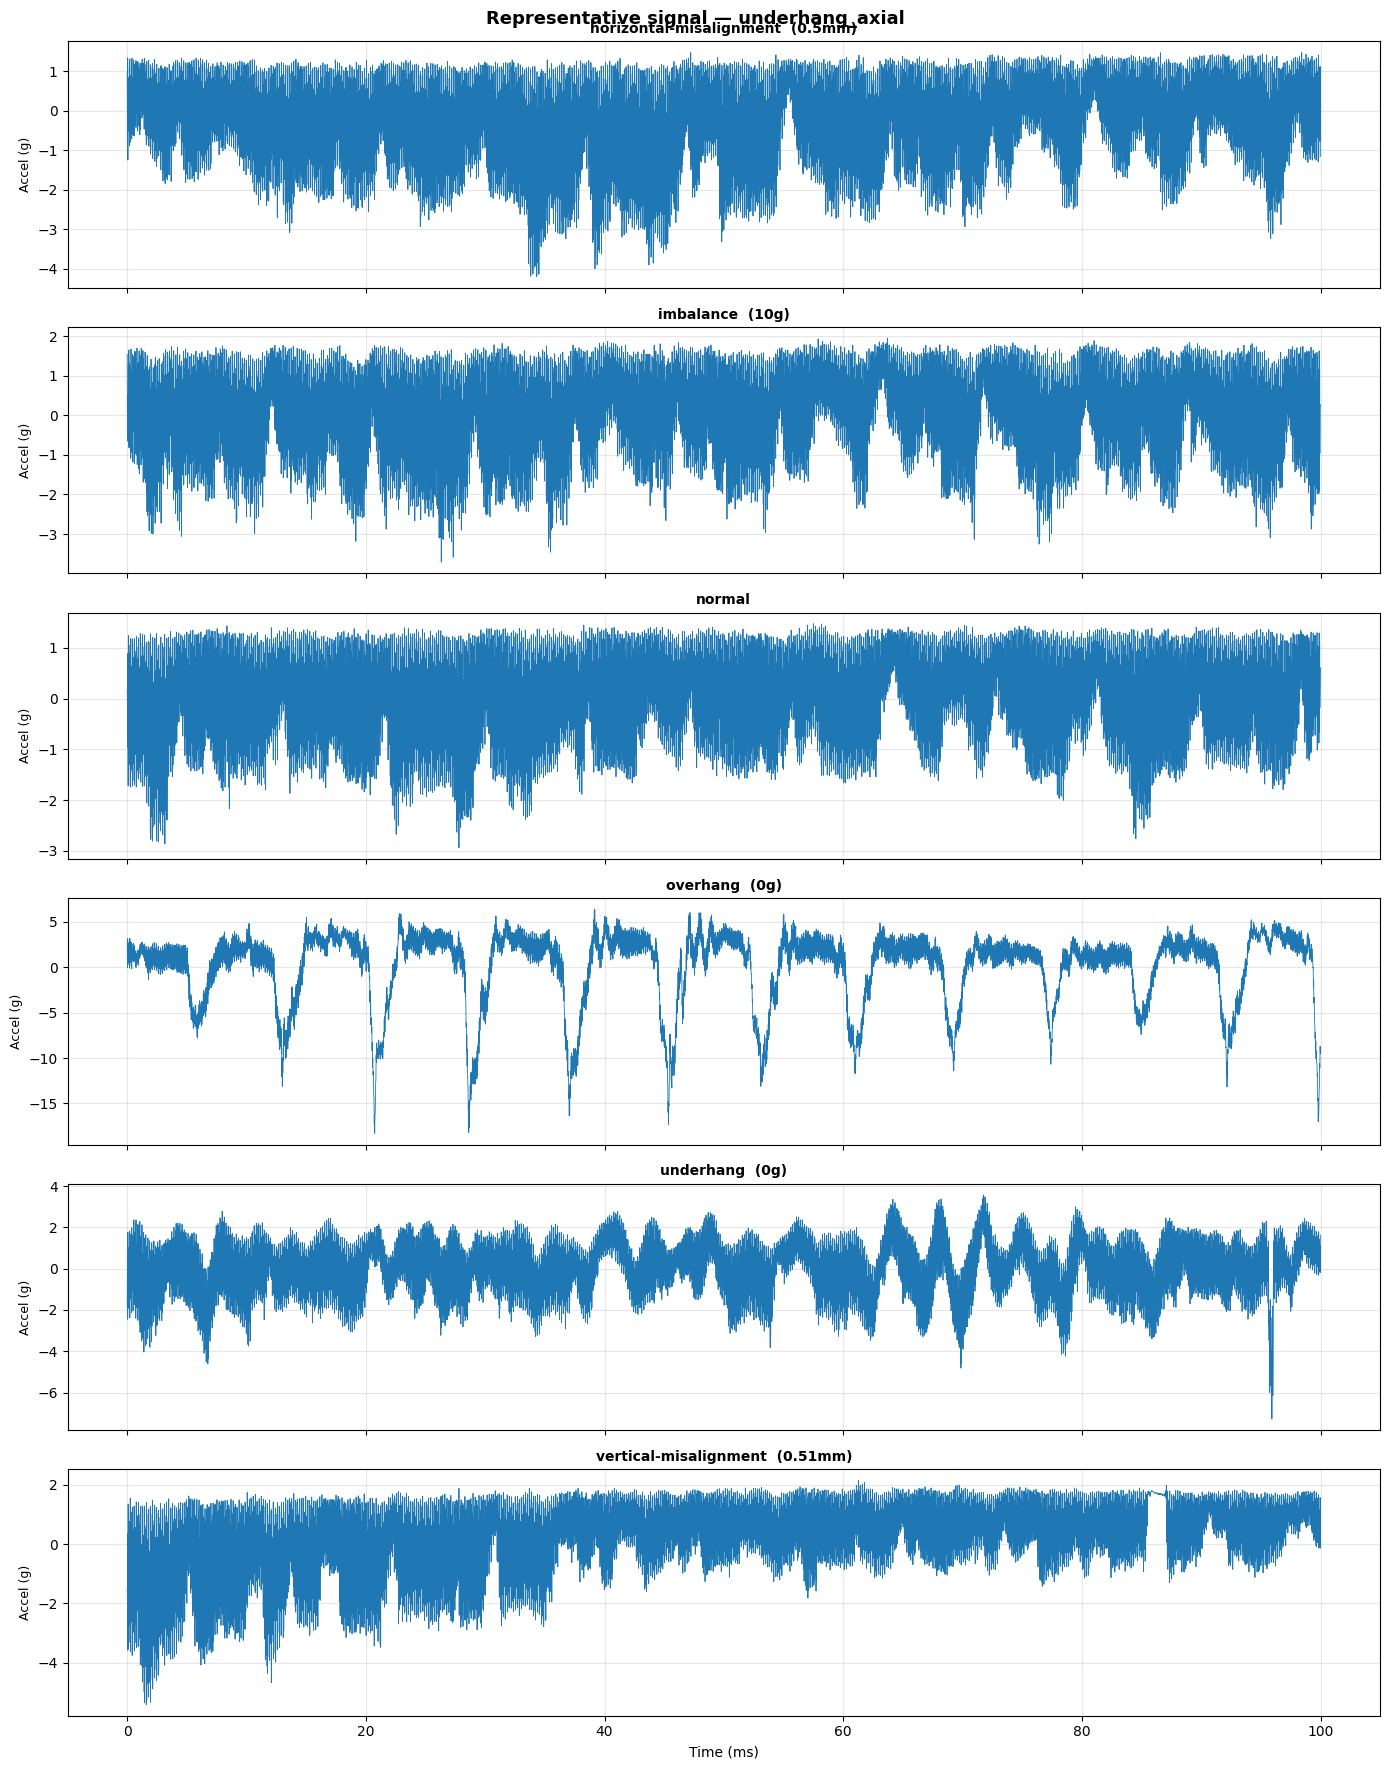

In [13]:
FAULT_TYPES = metadata["fault_category"].unique()
CHANNEL     = "underhang_axial"
N_SAMPLES   = 5_000  # first 0.1 s at 50 kHz — enough to see waveform character

fig, axes = plt.subplots(len(FAULT_TYPES), 1, figsize=(14, 3 * len(FAULT_TYPES)), sharex=True)
t = np.arange(N_SAMPLES) / SAMPLING_RATE * 1000  # ms

for ax, fault in zip(axes, FAULT_TYPES):
    sample_path = metadata.loc[metadata["fault_category"] == fault, "file_path"].iloc[0]
    df = pd.read_csv(sample_path, header=None, names=CHANNEL_NAMES)
    
    severity = metadata.loc[metadata["fault_category"] == fault, "severity"].iloc[0]
    label    = fault if severity is None else f"{fault}  ({severity})"

    ax.plot(t, df[CHANNEL].values[:N_SAMPLES], linewidth=0.6)
    ax.set_ylabel("Accel (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Representative signal — {CHANNEL}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

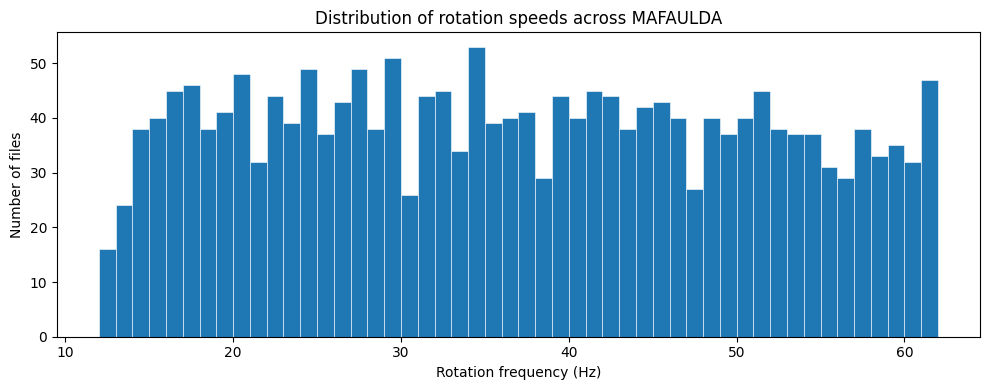

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(metadata["frequency_hz"], bins=50, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Rotation frequency (Hz)")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of rotation speeds across MAFAULDA")

plt.tight_layout()

plt.show()

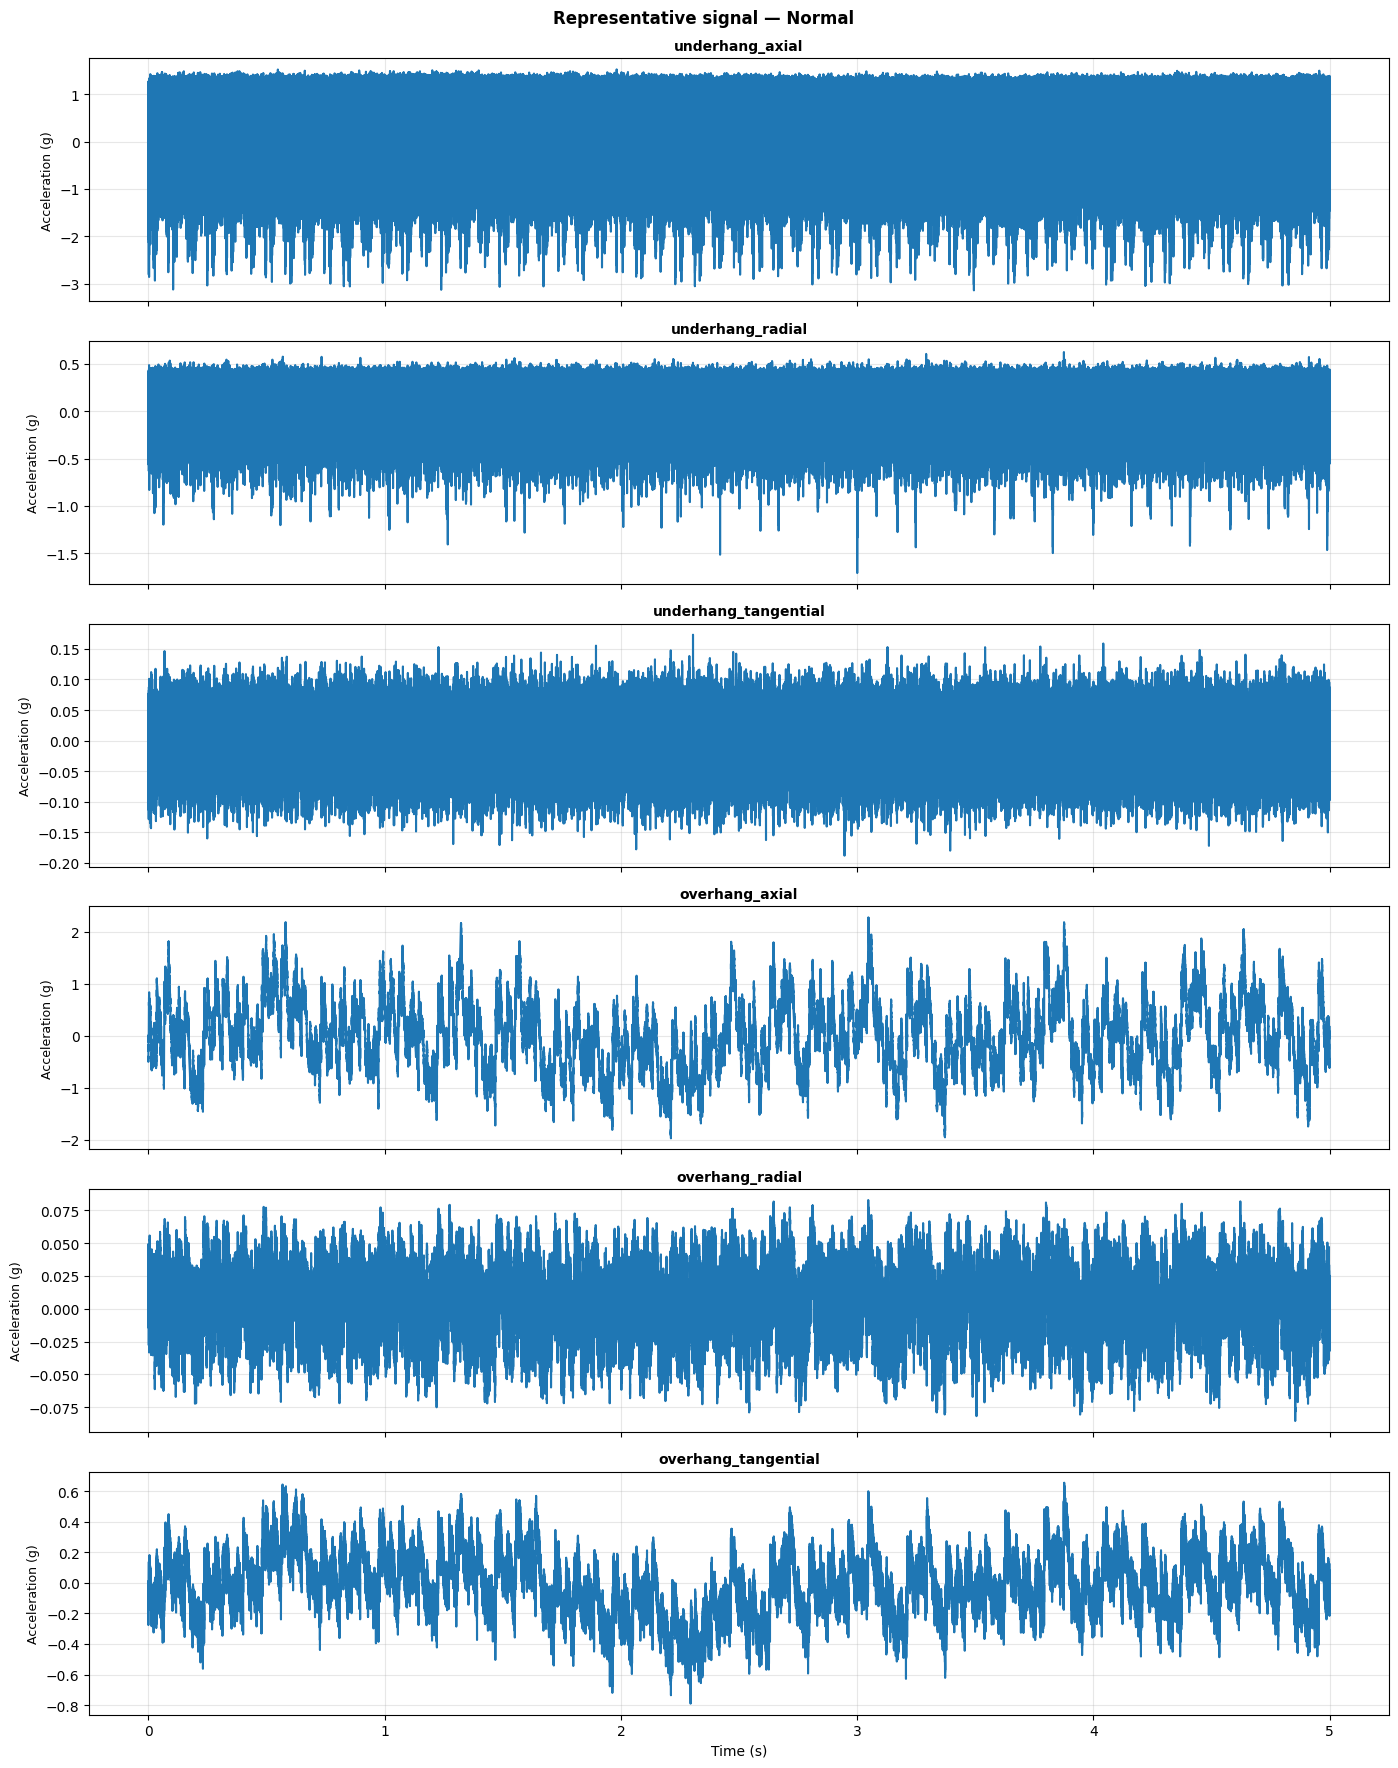

In [33]:
ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

FAULT_TYPES = metadata["fault_category"].unique()
CHANNEL     = "underhang_axial"
# CHANNEL_NAMES
N_SAMPLES   = 5_000  # first 0.1 s at 50 kHz — enough to see waveform character

fig, axes = plt.subplots(len(ACCEL_CHANNELS), 1, figsize=(14, 3 * len(ACCEL_CHANNELS)), sharex=True)

sample_path = metadata.loc[metadata["fault_category"] == "normal", "file_path"].iloc[0]
df = pd.read_csv(sample_path, header=None, names=CHANNEL_NAMES)

fs = 50_000  # Hz — MAFAULDA's sampling rate
n_samples = len(df)
time = np.arange(n_samples) / fs  # seconds

for ax, accel_ch in zip(axes, ACCEL_CHANNELS):
    label    =  f"{accel_ch}"
    ax.plot(time, df[accel_ch].values)
    ax.set_ylabel("Acceleration (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Representative signal — Normal", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()